In [182]:
# Import Libraries and Configure Matplotlib
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import re
import collections
from matplotlib import cm
from matplotlib import colors
from pycirclize import Circos
from tqdm import tqdm
import glob
import pandas as pd
import sys
import importlib
sys.path.append('/Users/xuechenkan/potts_model_test/')  # Adjust the path as needed

from utilities.functions import *
import utilities.functions as functions

# Reload the module to reflect the changes
importlib.reload(functions)

<module 'utilities.functions' from '/Users/xuechenkan/potts_model_test/utilities/functions.py'>

In [183]:
start_aa = 1  # Starting amino acid position
actual_length = 263
IN_path = '/Users/xuechenkan/potts_model_test/ms0.5/IN/'
PR_path = '/Users/xuechenkan/potts_model_test/ms0.5/PR/'
RT_path = '/Users/xuechenkan/potts_model_test/ms0.5/RT/'
IN_unreduced_seq_path = '/Users/xuechenkan/potts_model_test/ms1/IN/data/in.fullseq'

IN_redux_dict = get_redu_dict(IN_path+'data/in.reduce4.redux',1)
PR_redux_dict = get_redu_dict(PR_path+'data/pr.reduce4.redux',0)
RT_redux_dict = get_redu_dict(RT_path+'data/rt.reduce4.redux',0)

In [184]:
#outer rim with ticks every 10 amino acids and labels for every 10th tick
def initialize_circos(seq_length):
    """
    Initialize Circos with a single sector for nl43 ΔΔE and configure the main arc and ticks.
    """
    # Initialize Circos with a single sector for nl43 ΔΔE

    sectors = {"nl43 ΔΔE": seq_length}
    circos = Circos(sectors, space=0, start=0, end=340)

    # Get the sector
    sector = circos.get_sector("nl43 ΔΔE")

    # Add outer track for the main arc
    track1 = sector.add_track((96, 98))
    track1.rect(0, seq_length, fc="grey", ec="grey", lw=1.0)

    # Add ticks and labels
    major_ticks_pos = list(range(0, seq_length, 10))
    major_ticks_labels = [str(i+1) if (i+1) % 10 == 1 else "" for i in major_ticks_pos]
    all_ticks_pos = list(range(0, seq_length, 1))
    all_ticks_labels = None

    track1.xticks(major_ticks_pos, major_ticks_labels, label_size=10, tick_length=2, outer=False)
    track1.xticks(all_ticks_pos, all_ticks_labels, label_size=8, tick_length=1, outer=False)

    # Return the initialized Circos and sector
    return circos, sector

# Call the function
circos, sector = initialize_circos(actual_length)



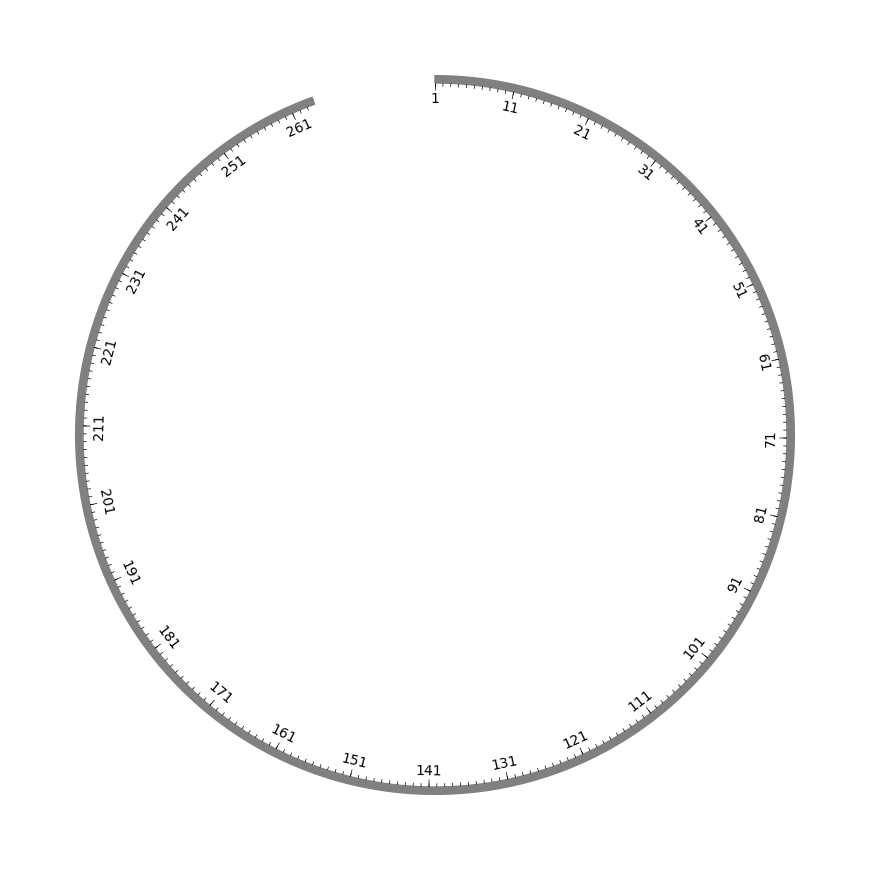

In [185]:
fig = circos.plotfig()
plt.show()

In [186]:

tsv_files = glob.glob("data/drug_resistant*.tsv")
# Create dictionary for NRTI and NNRTI resistance mutations
# Read and merge from all drug_resistant*.tsv files
def create_resistance_mutations(tsv_files):
    """
    Create a dictionary for resistance mutations from a list of TSV files.

    Parameters:
    tsv_files (list): List of file paths to TSV files.

    Returns:
    dict: A dictionary containing resistance mutations.
    """
    # Initialize the resistance_mutations dictionary structure
    resistance_mutations = {
        "Drug_Resistant": {
            "positions": [],
            "consensus": [],
            "mutations": []
        }
    }

    # Read and merge all TSV files
    all_drms = []
    for file in tsv_files:
        try:
            df = pd.read_csv(file, sep='\t')
            # Rename columns to standard format if needed
            if 'PositionConsensus' in df.columns:
                df = df.rename(columns={'PositionConsensus': 'Position'})
            all_drms.append(df[['Position', 'Consensus', 'DRM']])
        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue

    # Combine all dataframes
    if all_drms:
        combined_df = pd.concat(all_drms, ignore_index=True)

        # Group by position and consensus to collect all mutations
        grouped = combined_df.groupby(['Position', 'Consensus'])['DRM'].apply(lambda x: ''.join(sorted(set(x)))).reset_index()

        # Populate the resistance_mutations dictionary
        for _, row in grouped.iterrows():
            resistance_mutations["Drug_Resistant"]["positions"].append(int(row['Position']))
            resistance_mutations["Drug_Resistant"]["consensus"].append(row['Consensus'])
            resistance_mutations["Drug_Resistant"]["mutations"].append(row['DRM'])
    else:
        print("No drug resistant TSV files found or readable")

    return resistance_mutations

# Call the function with the list of TSV files
resistance_mutations = create_resistance_mutations(tsv_files)

print("Resistance Mutations Dictionary created:")
for category, data in resistance_mutations.items():
    print(f"\nCategory: {category}")
    print(f"Positions: {data['positions']}")
    print(f"Consensus: {data['consensus']}")

Resistance Mutations Dictionary created:

Category: Drug_Resistant
Positions: [51, 66, 74, 75, 92, 95, 97, 118, 121, 122, 138, 140, 143, 145, 146, 147, 148, 151, 153, 155, 157, 163, 230, 232, 263]
Consensus: ['H', 'T', 'L', 'V', 'E', 'Q', 'T', 'G', 'F', 'T', 'E', 'G', 'Y', 'P', 'Q', 'S', 'Q', 'V', 'S', 'N', 'E', 'G', 'S', 'D', 'R']


In [187]:
def add_DR_annotation_track(resistance_mutations):
    """
    Add an annotation track for mutations to the Circos plot.

    Parameters:
    resistance_mutations (dict): Dictionary containing mutation data with keys 'positions', 'consensus', and 'mutations'.
    """
    # Add annotation track for mutations
    annotation_track = sector.add_track((90, 100))

    # Annotate each mutation position
    annotated_positions = set()  # Track annotations to avoid duplicates
    for category in resistance_mutations.keys():
        for i, pos in enumerate(resistance_mutations[category]["positions"]):
            
            circos_pos = pos - start_aa  # Adjust position to start from start_aa
            consensus = resistance_mutations[category]["consensus"][i]

            # Ensure circos_pos is within the valid range of the sector
            if circos_pos < 0 or circos_pos >= sector.size:
                print(f"Skipping position {pos} as it is out of range for the sector.")
                continue

            # Create label with consensus and position
            label = f"{consensus}{pos}"

            # Check if this position has already been annotated
            if (consensus, pos) not in annotated_positions:
                annotation_track.annotate(circos_pos, label, label_size=13, shorten=100)
                annotated_positions.add((consensus, pos))

add_DR_annotation_track(resistance_mutations)

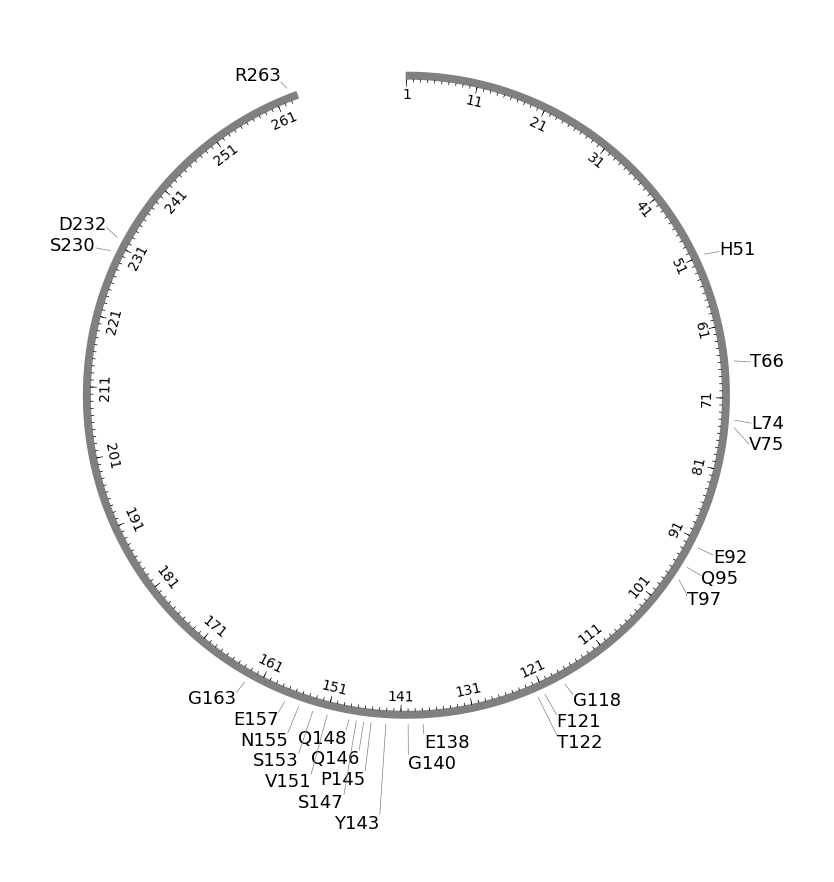

In [188]:
fig = circos.plotfig()
plt.show()

In [189]:
def process_delta_e_by_positions(file_path):
    """
    Process delta E and delta delta E values from a file.

    Parameters:
    file_path (str): Path to the input file.
    mutation_map (dict): Mapping of amino acids to indices.

    Returns:
    tuple: A tuple containing delta_e_per_position (defaultdict) and delta_delta_e_per_pair (list).
    """
    # Initialize dictionaries to store delta E and delta delta E values
    delta_e_per_position = collections.defaultdict(lambda: [0.0, 0.0, 0.0, 0.0])
    delta_delta_e_per_pair = []
    mutation_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

    # Read the file and process the data
    with open(file_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            columns = re.split(r'[,\t\s]+', line)
            mutations = columns[0]
            ddE = float(columns[1])
            delta_e1 = float(columns[3])
            delta_e2 = float(columns[4])

            # Extract positions from the mutation string
            positions = [int(pos) for pos in re.findall(r'\d+', mutations)]
            if len(positions) != 2:
                continue

            pos1, pos2 = positions

            # Detect the wildtype 'first' amino acid sequence
            wildtype_aa1 = mutations[0]  # Extract the first amino acid from the mutation string
            wildtype_aa2 = mutations.split('-')[1][0]  # Extract the first letter after '-'
            mutate_aa1 = mutations[mutations.index('-') - 1]  # Extract the one letter before '-'
            mutate_aa2 = mutations[-1]

            # Map the wildtype amino acid to the corresponding index in the delta_e_per_position list
            if mutate_aa1 in mutation_map:
                delta_e_per_position[pos1][mutation_map[mutate_aa1]] = delta_e1
            if mutate_aa2 in mutation_map:
                delta_e_per_position[pos2][mutation_map[mutate_aa2]] = delta_e2

            # Store delta delta E values for each pair of positions
            delta_delta_e_per_pair.append((pos1, pos2, ddE))

    return delta_e_per_position


# Call the function
file_path = 'data/kn.her2.all'
delta_e_per_position = process_delta_e_by_positions(file_path)

print("Delta E per position:")
for pos, values in delta_e_per_position.items():
    print(f"Position {pos}: {values}")


Delta E per position:
Position 1: [0.0, -8.38054968975, -8.25988974422, -8.39492220245]
Position 2: [-12.211337151, 0.0, -8.17965538055, -8.33986726217]
Position 3: [0.0, -6.41973451525, -5.49322355539, -9.96717477869]
Position 4: [0.0, -8.36709472165, -8.3004519064, -8.35169317573]
Position 5: [0.0, -8.17220654339, -8.27075589634, -8.31584165618]
Position 6: [-9.06889346242, 0.0, -5.50562496949, -4.18481978937]
Position 7: [-5.98517650831, -5.61920403084, 0.0, -4.31459438428]
Position 8: [-8.27113418095, 0.0, -8.27854509838, -8.24168222211]
Position 9: [0.0, -9.04177383147, -8.32005050592, -8.229754081]
Position 10: [-9.37142550806, -3.09506198578, 0.0, -8.13631128939]
Position 11: [0.0, -1.0387032833, -7.74111969257, -7.73570646672]
Position 12: [-9.39522261359, 0.0, -8.37496166117, -8.32128112204]
Position 13: [0.0, -9.00118947774, -8.54242528137, -8.4419245841]
Position 14: [0.0, -2.12882483751, -7.94176133489, -7.84364479827]
Position 15: [-10.9412949849, -7.13887907099, 0.0, -8.1

In [190]:
# Create a dictionary to store the filtered delta E values for each position
def filter_delta_e_by_positions(delta_e_per_position):
    """
    Filter delta E values for specific positions.

    Parameters:
    delta_e_per_position (dict): Dictionary containing delta E values for each position.
    positions_to_filter (list): List of positions to filter.

    Returns:
    dict: A dictionary containing filtered delta E values for the specified positions.
    """
    # mutation_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    mutation_map_re = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
    filtered_delta_e_dict = collections.defaultdict(list)
    IN_redux_dict = get_redu_dict(IN_path+'data/in.reduce4.redux',1)
    IN_unreduced_seq = read_seq(IN_unreduced_seq_path)
    for pos in range(1, actual_length + 1):
        curr_Wildtype = mutation_map_re[[i for i in range(4) if delta_e_per_position[pos][i] == 0.0][0]] # Get the wildtype amino acid for the current position
        for index in range(4):

            curr_Mutant = mutation_map_re[index]
            reduced_pair = (f"{curr_Wildtype}{pos}{curr_Mutant}")
            unreduced_pair = reduced_to_unreduced(IN_redux_dict,reduced_pair, IN_unreduced_seq)
            unreduced_mutant = unreduced_pair[-1]
            unreduced_pos = int(re.findall(r'\d+', unreduced_pair)[0])
            
            if delta_e_per_position[pos][index] != 0.0 and (calculate_freq(unreduced_mutant,unreduced_pos, IN_unreduced_seq) > 1/100):
                filtered_delta_e_dict[pos].append(delta_e_per_position[pos][index])
                print(f"Position: {pos}, Wildtype: {curr_Wildtype}, Mutant: {curr_Mutant}, Reduced Pair: {reduced_pair}, Unreduced Pair: {unreduced_pair}, Delta E: {delta_e_per_position[pos][index]}, Frequency: {calculate_freq(unreduced_mutant,unreduced_pos, IN_unreduced_seq)}")
    return filtered_delta_e_dict

# filtered_delta_e_dict[pos].append(delta_e_per_position[pos][index])
filtered_delta_e_dict = filter_delta_e_by_positions(delta_e_per_position)
# Print the filtered delta E dictionary
print("Filtered delta E dictionary:")
for pos, values in filtered_delta_e_dict.items():
    print(f"Position {pos}: {values}")

Position: 6, Wildtype: B, Mutant: C, Reduced Pair: B6C, Unreduced Pair: D6E, Delta E: -5.50562496949, Frequency: 0.04180327868852459
Position: 7, Wildtype: C, Mutant: B, Reduced Pair: C7B, Unreduced Pair: K7E, Delta E: -5.61920403084, Frequency: 0.010655737704918032
Position: 7, Wildtype: C, Mutant: D, Reduced Pair: C7D, Unreduced Pair: K7R, Delta E: -4.31459438428, Frequency: 0.03360655737704918
Position: 10, Wildtype: C, Mutant: B, Reduced Pair: C10B, Unreduced Pair: E10D, Delta E: -3.09506198578, Frequency: 0.08114754098360656
Position: 11, Wildtype: A, Mutant: B, Reduced Pair: A11B, Unreduced Pair: E11D, Delta E: -1.0387032833, Frequency: 0.21065573770491802
Position: 13, Wildtype: A, Mutant: B, Reduced Pair: A13B, Unreduced Pair: E13D, Delta E: -9.00118947774, Frequency: 0.013934426229508197
Position: 14, Wildtype: A, Mutant: B, Reduced Pair: A14B, Unreduced Pair: K14R, Delta E: -2.12882483751, Frequency: 0.0942622950819672
Position: 17, Wildtype: D, Mutant: A, Reduced Pair: D17A,

In [191]:
# Find the largest and smallest values in filtered_delta_e_dict
largest_value = max(max(values) for values in filtered_delta_e_dict.values() if values)
smallest_value = min(min(values) for values in filtered_delta_e_dict.values() if values)

print(f"Largest value in filtered_delta_e_dict: {largest_value}")
print(f"Smallest value in filtered_delta_e_dict: {smallest_value}")

Largest value in filtered_delta_e_dict: 4.31411333755
Smallest value in filtered_delta_e_dict: -10.1387288552


now add in a line track with the above filtered_delta_e_values, and color the areas like this code example:

from pycirclize import Circos
import numpy as np
np.random.seed(0)

sectors = {"A": 10, "B": 20, "C": 15}
circos = Circos(sectors, space=5)
for sector in circos.sectors:
    track = sector.add_track((80, 100), r_pad_ratio=0.1)
    track.axis()
    track.xticks_by_interval(1)
    vmin, vmax = 0, 10
    # Line between start-end two points
    track.line([track.start, track.end], [vmin, vmax], lw=1.5, ls="dotted")
    # Line of random value points
    x = np.linspace(track.start, track.end, int(track.size) * 5 + 1)
    y = np.random.randint(vmin, vmax, len(x))
    track.line(x, y)
fig = circos.plotfig()


/var/folders/17/rj19bvws2qscyfjmb7m44zmm0000gn/T/ipykernel_18905/259637896.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  scatter_cmap_positive = cm.get_cmap("Purples")
/var/folders/17/rj19bvws2qscyfjmb7m44zmm0000gn/T/ipykernel_18905/259637896.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  scatter_cmap_negative = cm.get_cmap("Oranges_r")


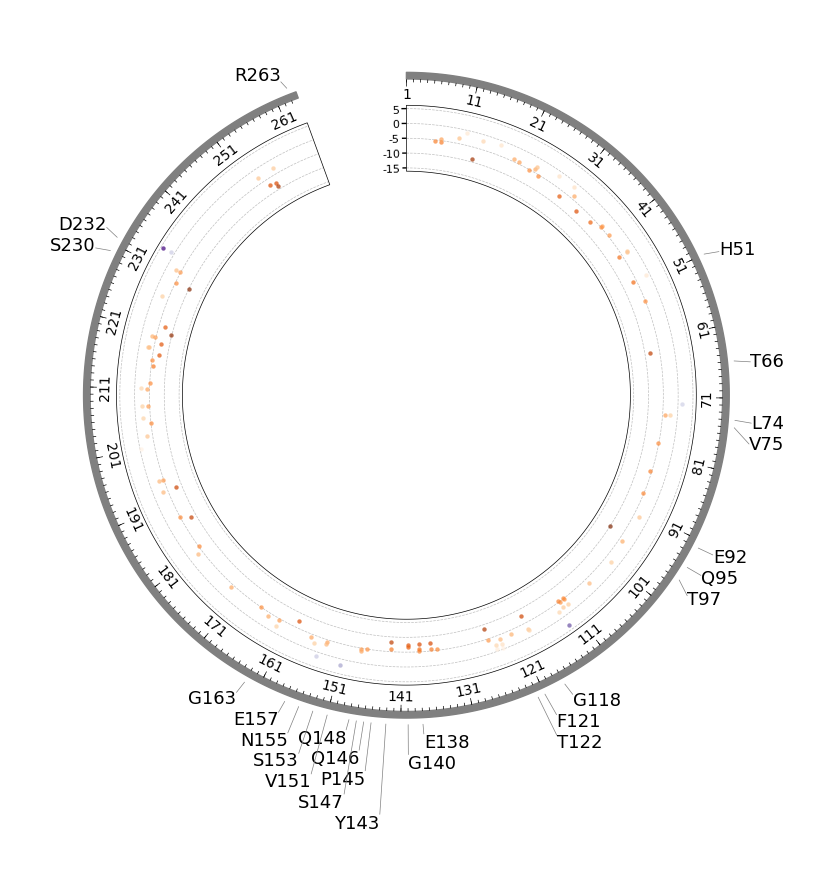

In [192]:
def add_filtered_delta_e_track(filtered_delta_e_dict):
    """
    Add a line track for filtered delta E values to the Circos plot.

    Parameters:
    filtered_delta_e_dict (dict): Dictionary containing filtered delta E values for each position.
    """
    # Add a line track for filtered_delta_e_values
    line_track = sector.add_track((68, 88), r_pad_ratio=0.1)
    line_track.axis()
    
    # Configure axis and ticks
    line_track.yticks(
        [0, 5, 10, 15, 20],  # Positions
        ["-15", "-10", "-5", "0", "5"],  # Labels
        side="left",
        line_kws=dict(color="black", lw=1),
        text_kws=dict(color="black", size=8)
    )

    # Add grid lines for the values
    line_track.grid(
        y_grid_num=5,  # Number of grid lines
        color="grey",
        lw=0.5,
        ls="--"
    )

    # Define the color map for the scatter plot
    scatter_cmap_positive = cm.get_cmap("Purples")
    scatter_cmap_negative = cm.get_cmap("Oranges_r")
    scatter_norm_positive = colors.Normalize(vmin=0, vmax=largest_value)
    scatter_norm_negative = colors.Normalize(vmin=smallest_value, vmax=0)

    # Plot all the delta E values from filtered_delta_e_dict
    for x_key, y_values in filtered_delta_e_dict.items():
        # Add 15 to each y value and plot it on the grid
        for y_value in y_values:
            if y_value >= 0:
                adjusted_color = scatter_cmap_positive(scatter_norm_positive(y_value))
            else:
                adjusted_color = scatter_cmap_negative(scatter_norm_negative(y_value))
            line_track.scatter([x_key - 1], [(y_value + 15)], vmax=20, s=10, color=adjusted_color, alpha=0.7)

    # Plot the figure
    fig = circos.plotfig()
    plt.show()

# Call the function with the filtered_delta_e_dict
add_filtered_delta_e_track(filtered_delta_e_dict)


/var/folders/17/rj19bvws2qscyfjmb7m44zmm0000gn/T/ipykernel_18905/543428386.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  chord_cmap = cm.get_cmap("bwr_r")


Antagonistic max (min ddE): -2.31686
Synergistic min (max ddE): 8.50879


Processing DR chords: 100%|██████████| 26/26 [00:00<00:00, 2101.52it/s]


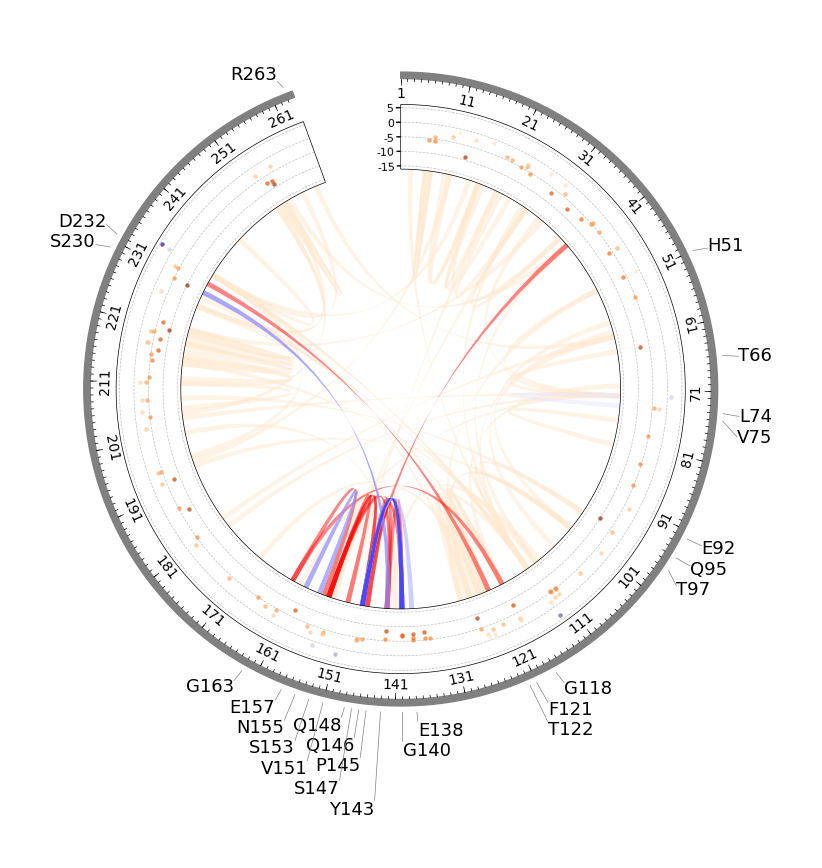

In [193]:
import pandas as pd

# Add a track for the chords spanning 0-40
# chord_track = sector.add_track((0, 40))
# Calculate the actual min and max values of ddE from the data
df = pd.read_csv('data/IN_all_100pairs.tsv', sep='\t')
anta_max = df[df['DR_position'] == 1]['ddE'].min()
syner_min = df[df['DR_position'] == 1]['ddE'].max()

print(f"Antagonistic max (min ddE): {anta_max}")
print(f"Synergistic min (max ddE): {syner_min}")

# Define the color map for the chords
chord_cmap = cm.get_cmap("bwr_r")
chord_norm = colors.Normalize(vmin=anta_max, vmax=syner_min)
thickness = 1
background_thickness = 1
thickness_d2 = thickness/2
background_thickness_d2 = background_thickness/2

##########################background chords for drug resistant positions###############################
# Read the data from the TSV file
df = pd.read_csv('data/IN_all_100pairs.tsv', sep='\t')
# df['DR_position'] = 0

# # Add a DR_position column based on ddE values

# Filter for DR_position = 0 (background chords)
background_pairs = df[df['DR_position'] == 0]

# Add background chords
for _, row in tqdm(background_pairs.iterrows(), total=len(background_pairs), desc="Processing background chords"):
    pos1, pos2, dde = row['pos1'], row['pos2'], row['ddE']
    
    # Define regions for the chord
    region1 = ("nl43 ΔΔE", pos1 - background_thickness_d2 - start_aa, pos1 + background_thickness_d2 - start_aa)
    region2 = ("nl43 ΔΔE", pos2 - background_thickness_d2 - start_aa, pos2 + background_thickness_d2 - start_aa)
    
    # Check if the regions are within valid bounds
    if region1[1] < 0 or region1[2] > actual_length or region2[1] < 0 or region2[2] > actual_length:
        continue
    
    # Use light gray color for background
    light_gray_color = "#ffe9cf"
    circos.link(region1, region2, color=light_gray_color)

##########################highlighted chords for drug resistant positions###############################

# Filter for DR_position = 1 (drug resistant pairs)
df = pd.read_csv('data/IN_all_100pairs.tsv', sep='\t')
dr_pairs = df[df['DR_position'] == 1]

# Add drug resistant chords with the same style as background
for _, row in tqdm(dr_pairs.iterrows(), total=len(dr_pairs), desc="Processing DR chords"):
    pos1, pos2, dde = row['pos1'], row['pos2'], row['ddE']
    
    # Define regions for the chord
    region1 = ("nl43 ΔΔE", pos1 - thickness_d2 - start_aa, pos1 + thickness_d2 - start_aa)
    region2 = ("nl43 ΔΔE", pos2 - thickness_d2 - start_aa, pos2 + thickness_d2 - start_aa)
    
    # Check if the regions are within valid bounds
    if region1[1] < 0 or region1[2] > actual_length or region2[1] < 0 or region2[2] > actual_length:
        continue
    
    # Map the delta delta E value to a color using the same colormap as the original selection

    color = chord_cmap(chord_norm(dde))
    
    # Add the chord to the circos plot
    circos.link(region1, region2, color=color, lw=0.01)

# Add a color bar for the chords
chord_mappable = cm.ScalarMappable(norm=chord_norm, cmap=chord_cmap)
fig = circos.plotfig()



add the above negative de and positive de graphs together, but shrik the length of the positive de colormap length by 10 times

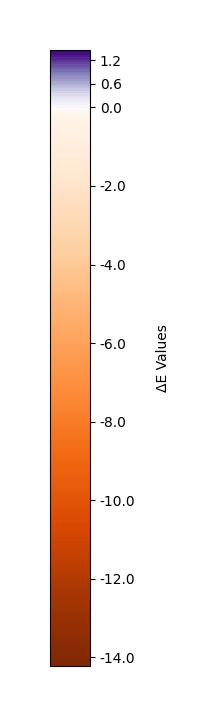

In [194]:
# Same setup as before but with vertical orientation and slimmer bar

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def shifted_cmap(cmap_neg, cmap_pos, vmin, vmax, vcenter, name="shiftedcmap"):
    """Create a shifted diverging colormap with two different cmaps."""
    midpoint = (vcenter - vmin) / (vmax - vmin)
    cdict = {"red": [], "green": [], "blue": []}

    # Negative side
    reg_index_neg = np.linspace(0, 1, 128, endpoint=False)
    shift_index_neg = np.linspace(0.0, midpoint, 128, endpoint=False)
    for ri, si in zip(reg_index_neg, shift_index_neg):
        r, g, b, _ = plt.cm.Oranges_r(ri)  # Use Oranges_r for negative values
        cdict["red"].append((si, r, r))
        cdict["green"].append((si, g, g))
        cdict["blue"].append((si, b, b))

    # Positive side
    reg_index_pos = np.linspace(0, 1, 129, endpoint=True)
    shift_index_pos = np.linspace(midpoint, 1.0, 129, endpoint=True)
    for ri, si in zip(reg_index_pos, shift_index_pos):
        r, g, b, _ = plt.cm.Purples(ri)  # Use Purples for positive values
        cdict["red"].append((si, r, r))
        cdict["green"].append((si, g, g))
        cdict["blue"].append((si, b, b))

    newcmap = mpl.colors.LinearSegmentedColormap(name, cdict)
    return newcmap


# Original values from filtered_delta_e_dict
data_min = -14.1431021132
data_max = 1.38276502956

# Add 0.5% padding
padding = 0.005 * (data_max - data_min)
vmin = data_min - padding
vmax = data_max + padding
vcenter = 0

# Tick positions (unchanged)
neg_ticks = np.array([-14, -12, -10, -8, -6, -4, -2, 0])
pos_ticks = np.array([0.6, 1.2])
all_ticks = np.concatenate([neg_ticks, pos_ticks])

# Build shifted cmap with Reds_r and Blues
cmap = shifted_cmap(plt.cm.Reds_r, plt.cm.Blues, vmin, vmax, vcenter)
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Plot with vertical orientation and slimmer bar
fig, ax = plt.subplots(figsize=(1, 8))
fig.subplots_adjust(left=0.5)

cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation="vertical")
cb.set_ticks(all_ticks)
cb.set_ticklabels([str(t) for t in all_ticks])

cb.set_label("ΔE Values", rotation=90, labelpad=15)
plt.show()



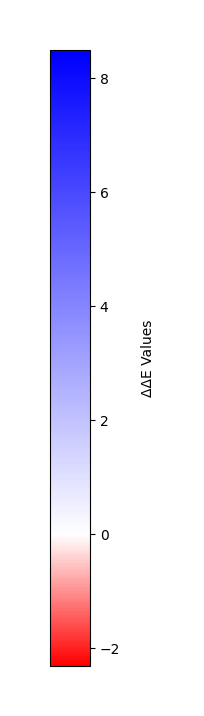

In [195]:
def shifted_cmap_bwr_vibrant(cmap, vmin, vmax, vcenter, name="shiftedcmap_bwr_vibrant"):
    """Create a shifted diverging colormap using vibrant tones of bwr."""
    midpoint = (vcenter - vmin) / (vmax - vmin)
    cdict = {"red": [], "green": [], "blue": []}

    # Negative side (vibrant tones of bwr)
    reg_index_neg = np.linspace(0, 0.5, 128, endpoint=False)
    shift_index_neg = np.linspace(0.0, midpoint, 128, endpoint=False)
    for ri, si in zip(reg_index_neg, shift_index_neg):
        r, g, b, _ = cmap(ri)
        cdict["red"].append((si, r, r))
        cdict["green"].append((si, g, g))
        cdict["blue"].append((si, b, b))

    # Positive side (vibrant tones of bwr)
    reg_index_pos = np.linspace(0.5, 1, 129, endpoint=True)
    shift_index_pos = np.linspace(midpoint, 1.0, 129, endpoint=True)
    for ri, si in zip(reg_index_pos, shift_index_pos):
        r, g, b, _ = cmap(ri)
        cdict["red"].append((si, r, r))
        cdict["green"].append((si, g, g))
        cdict["blue"].append((si, b, b))

    newcmap = mpl.colors.LinearSegmentedColormap(name, cdict)
    return newcmap


# Define the range for the new colormap
vmin_new = -2.31
vmax_new = 8.5
vcenter_new = 0

# Create the shifted colormap using vibrant tones of bwr
cmap_bwr_vibrant = shifted_cmap_bwr_vibrant(plt.cm.bwr_r, vmin_new, vmax_new, vcenter_new)
norm_bwr_vibrant = mpl.colors.Normalize(vmin=vmin_new, vmax=vmax_new)

# Plot the new colormap
fig, ax = plt.subplots(figsize=(1, 8))
fig.subplots_adjust(left=0.5)
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap_bwr_vibrant, norm=norm_bwr_vibrant, orientation="vertical")
cb.set_label("ΔΔE Values", rotation=90, labelpad=15)
plt.show()
